# 🎓 Hackathon ML — Previsione Abbandono Universitario (ENHANCED)
**Metrica target:** F1-Score Macro (Dropout vs Graduate)  
**Dataset:** `train_dropout.csv` (2904 record) · `test_dropout.csv` (726 record)  
**Output:** `my_submission.csv`

---
## Struttura del Notebook
1. Setup & Import
2. Caricamento Dati
3. EDA — Exploratory Data Analysis (rapida)
4. Feature Engineering Avanzato (22 feature sintetiche)
🆕 **4B. Valutazione Feature — Mutual Information & Ridondanza**
5. Preprocessing Strategico
🆕 **5B. Pipeline Anti-Data Leakage**
6. Modellazione + Cross-Validation (RF · XGBoost · LightGBM)
🆕 **6B. Hyperparameter Tuning — GridSearchCV**
7. Ensemble con Modelli Ottimizzati
8. Feature Importance MDI
🆕 **8B. Permutation Importance — Validazione Robusta**
9. Generazione Submission Finale


## 🔍 Diagnosi del Notebook Originale — Cosa abbiamo migliorato

Questa versione del notebook aggiunge **4 sezioni nuove** e corregge i problemi metodologici presenti nella versione precedente.

### Problemi trovati e relative correzioni

| # | Problema | Impatto | Soluzione adottata |
|---|----------|---------|-------------------|
| 1 | **Data Leakage — Imputer fuori dalla CV** | Mediana calcolata su tutto il train (incluse val-folds) | `SimpleImputer` dentro `Pipeline` |
| 2 | **RobustScaler calcolato ma mai usato** | Bug silenzioso: i modelli ricevono dati non scalati | Pipeline esplicita con scaler opzionale |
| 3 | **Normalizzazione GDP globale in `add_features`** | Leakage debole sulle feature macro | GDP-norm spostato dentro Pipeline via `FunctionTransformer` |
| 4 | **Nessun tuning sistematico degli iperparametri** | Parametri scelti a mano → sub-ottimali | `GridSearchCV` su `Pipeline` (Sezione 6B) |
| 5 | **Feature Importance solo MDI** | Sovrastima feature ad alta cardinalità | Permutation Importance aggiunto (Sezione 8B) |
| 6 | **Valutazione feature sintetiche assente** | Non sappiamo quali delle 22 feature nuove contano | Mutual Information + Redundancy Analysis (Sezione 4B) |

> **Le sezioni originali 1–9 sono mantenute intatte** come baseline di confronto.  
> Le sezioni nuove sono marcate con `🆕`.


## 1. Setup & Import

In [7]:
# ── Installazione dipendenze (eseguire solo la prima volta) ──
# !pip install xgboost lightgbm imbalanced-learn --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Sklearn — base
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, RobustScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

# 🆕 Nuovi import per Pipeline, Imputer, Feature Selection
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif, SelectFromModel

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Seed globale per riproducibilità
SEED = 42
np.random.seed(SEED)

# Palette coerente
PALETTE = {'Dropout': '#E24B4A', 'Graduate': '#1D9E75'}

print('✅ Import completati — versione ENHANCED con Pipeline + GridSearchCV')


✅ Import completati — versione ENHANCED con Pipeline + GridSearchCV


## 2. Caricamento Dati

In [8]:
train = pd.read_csv('CSV/train_dropout.csv')
test  = pd.read_csv('CSV/test_dropout.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'\nColonne ({len(train.columns)}):')  
print(list(train.columns))

Train: (2904, 37)  |  Test: (726, 36)

Colonne (37):
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment 

In [9]:
# Verifica target
print('Distribuzione target:') 
print(train['Target'].value_counts())
print(f"\nRapporto Dropout/Graduate: {train['Target'].value_counts()['Dropout'] / train['Target'].value_counts()['Graduate']:.2f}")

Distribuzione target:
Target
Graduate    1767
Dropout     1137
Name: count, dtype: int64

Rapporto Dropout/Graduate: 0.64


## 3. EDA — Exploratory Data Analysis

In [10]:
# ── 3.1 Overview qualità dati ──
print('=== Valori mancanti ===' )
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Nessun valore mancante ✅')

print('\n=== Tipi di dato ===')
print(train.dtypes.value_counts())

print('\n=== Statistiche descrittive (prime 5 colonne numeriche) ===')
train.describe().T.head()

=== Valori mancanti ===
Nessun valore mancante ✅

=== Tipi di dato ===
int64      29
float64     7
str         1
Name: count, dtype: int64

=== Statistiche descrittive (prime 5 colonne numeriche) ===


,count,mean,std,min,25%,50%,75%,max
Marital status,2904.0,1.185606,0.613028,1.0,1.0,1.0,1.0,6.0
Application mode,2904.0,18.415289,17.335091,1.0,1.0,17.0,39.0,57.0
Application order,2904.0,1.746901,1.329204,0.0,1.0,1.0,2.0,6.0
Course,2904.0,8848.062328,2077.051948,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,2904.0,0.888430,0.314891,0.0,1.0,1.0,1.0,1.0


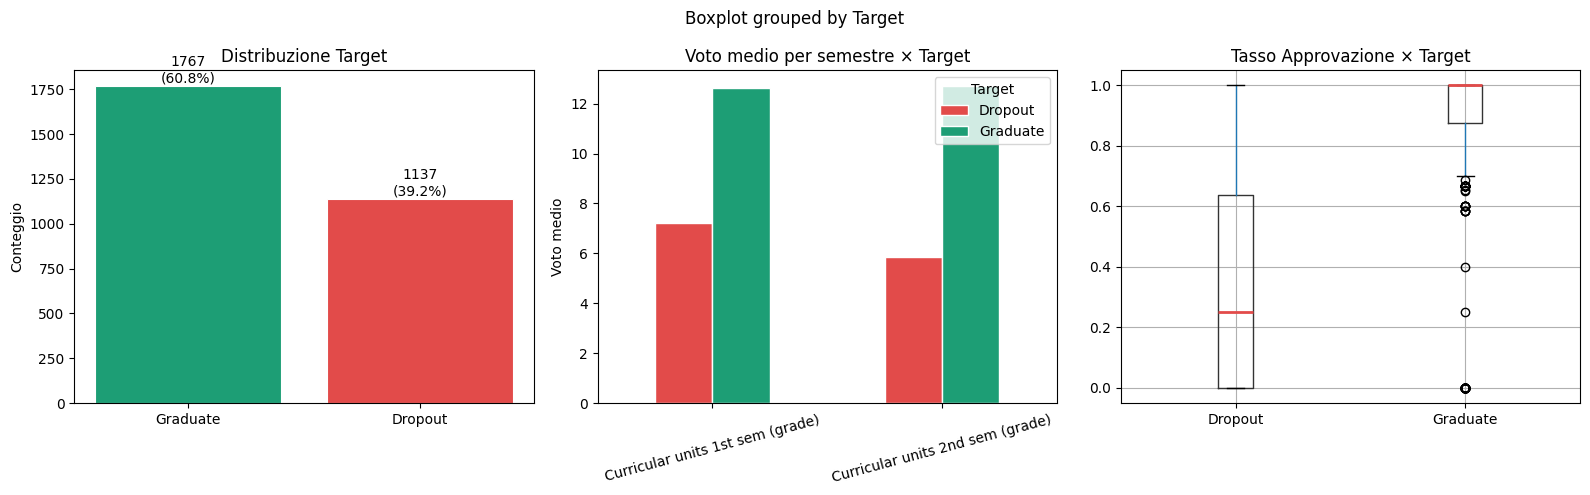

📊 EDA salvata in eda_overview.png


In [11]:
# ── 3.2 Distribuzione target ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Vista rapida', fontsize=14, fontweight='bold')

# Plot 1: distribuzione target
counts = train['Target'].value_counts()
colors = [PALETTE.get(c, '#888') for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribuzione Target')
axes[0].set_ylabel('Conteggio')
for i, (v, c) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(i, v + 20, f'{v}\n({v/len(train)*100:.1f}%)', ha='center', fontsize=10)

# Plot 2: voti medi per target
grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]
# Adattamento nomi colonne (lowercase)
grade_cols_found = [c for c in train.columns if 'grade' in c.lower() and 'sem' in c.lower()]
if len(grade_cols_found) >= 2:
    g1, g2 = grade_cols_found[:2]
    grade_data = train.groupby('Target')[[g1, g2]].mean()
    grade_data.T.plot(kind='bar', ax=axes[1], color=[PALETTE['Dropout'], PALETTE['Graduate']],
                      edgecolor='white', rot=15)
    axes[1].set_title('Voto medio per semestre × Target')
    axes[1].set_ylabel('Voto medio')
    axes[1].legend(title='Target')

# Plot 3: tasso approvazione per target
appr_cols = [c for c in train.columns if 'approved' in c.lower()]
enr_cols  = [c for c in train.columns if 'enrolled' in c.lower()]
if appr_cols and enr_cols:
    train_tmp = train.copy()
    train_tmp['approval_rate'] = (train_tmp[appr_cols].sum(axis=1) /
                                   (train_tmp[enr_cols].sum(axis=1) + 1e-6))
    train_tmp.boxplot(column='approval_rate', by='Target', ax=axes[2],
                      boxprops=dict(color='#333'),
                      medianprops=dict(color='#E24B4A', linewidth=2))
    axes[2].set_title('Tasso Approvazione × Target')
    axes[2].set_xlabel('')
    plt.sca(axes[2])
    plt.title('Tasso Approvazione × Target')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 EDA salvata in eda_overview.png')

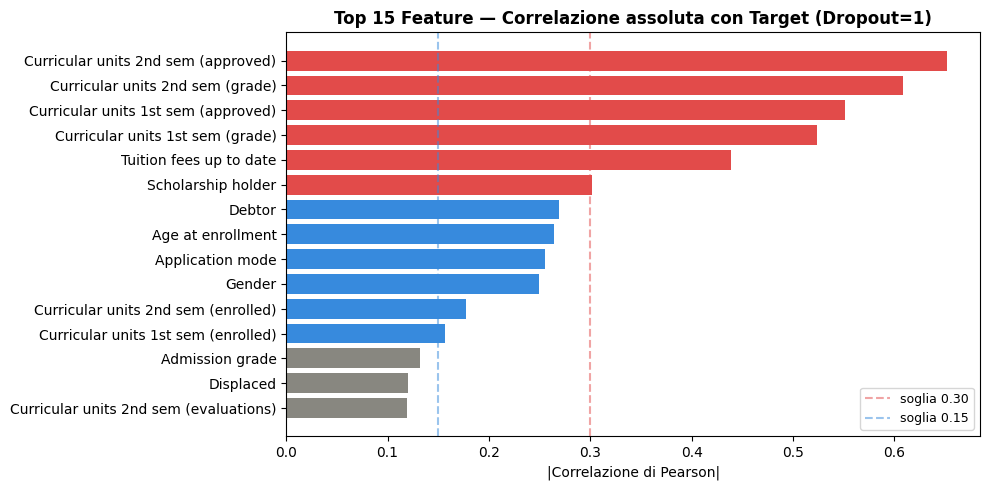

In [12]:
# ── 3.3 Correlazione feature numeriche con il target ──
train_enc = train.copy()
train_enc['Target_bin'] = (train_enc['Target'] == 'Dropout').astype(int)

num_cols = train_enc.select_dtypes(include=[np.number]).columns.tolist()
corr_target = (train_enc[num_cols]
               .corr()['Target_bin']
               .drop('Target_bin')
               .abs()
               .sort_values(ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#E24B4A' if v > 0.3 else '#378ADD' if v > 0.15 else '#888780'
              for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_bar[::-1])
ax.set_title('Top 15 Feature — Correlazione assoluta con Target (Dropout=1)', fontweight='bold')
ax.set_xlabel('|Correlazione di Pearson|')
ax.axvline(0.3, color='#E24B4A', linestyle='--', alpha=0.5, label='soglia 0.30')
ax.axvline(0.15, color='#378ADD', linestyle='--', alpha=0.5, label='soglia 0.15')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering Avanzato
**22 feature sintetiche** organizzate in 5 famiglie semantiche.

In [13]:
def detect_columns(df):
    """Rileva automaticamente le colonne per nome (case-insensitive, parziale)."""
    cols = {c.lower(): c for c in df.columns}
    
    def find(keyword, sem=None):
        """Restituisce la prima colonna che contiene keyword (e sem se specificato)."""
        for k, v in cols.items():
            if keyword in k:
                if sem is None or f'{sem}st' in k or f'{sem}nd' in k:
                    return v
        return None
    
    mapping = {
        # Semestre 1
        'grade_1':    find('grade', 1),
        'approved_1': find('approved', 1),
        'enrolled_1': find('enrolled', 1),
        'eval_1':     find('evaluations', 1),
        'noeval_1':   find('without evaluations', 1) or find('without_eval', 1),
        'credited_1': find('credited', 1),
        # Semestre 2
        'grade_2':    find('grade', 2),
        'approved_2': find('approved', 2),
        'enrolled_2': find('enrolled', 2),
        'eval_2':     find('evaluations', 2),
        'noeval_2':   find('without evaluations', 2) or find('without_eval', 2),
        'credited_2': find('credited', 2),
        # Socio-economiche
        'age':        find('age'),
        'scholarship':find('scholarship'),
        'debtor':     find('debtor'),
        'tuition':    find('tuition'),
        'displaced':  find('displaced'),
        'special':    find('special needs') or find('educational special'),
        'mother_edu': find("mother's qualification") or find('mothers_qualification'),
        'father_edu': find("father's qualification") or find('fathers_qualification'),
        'unemploy':   find('unemployment'),
        'gdp':        find('gdp'),
        'inflation':  find('inflation'),
    }
    return mapping

# Test su train
col_map = detect_columns(train)
print('Mappa colonne rilevate:')
for k, v in col_map.items():
    status = '✅' if v else '❌ NON TROVATA'
    print(f'  {k:15s} → {v or status}')

Mappa colonne rilevate:
  grade_1         → Curricular units 1st sem (grade)
  approved_1      → Curricular units 1st sem (approved)
  enrolled_1      → Curricular units 1st sem (enrolled)
  eval_1          → Curricular units 1st sem (evaluations)
  noeval_1        → Curricular units 1st sem (without evaluations)
  credited_1      → Curricular units 1st sem (credited)
  grade_2         → Curricular units 2nd sem (grade)
  approved_2      → Curricular units 2nd sem (approved)
  enrolled_2      → Curricular units 2nd sem (enrolled)
  eval_2          → Curricular units 2nd sem (evaluations)
  noeval_2        → Curricular units 2nd sem (without evaluations)
  credited_2      → Curricular units 2nd sem (credited)
  age             → Age at enrollment
  scholarship     → Scholarship holder
  debtor          → Debtor
  tuition         → Tuition fees up to date
  displaced       → Displaced
  special         → Educational special needs
  mother_edu      → Mother's qualification
  father_edu   

In [14]:
EPS = 1e-6  # evita divisione per zero

def add_features(df, col_map):
    """
    Aggiunge 22 feature sintetiche al dataframe.
    Gestisce colonne mancanti con fallback a 0.
    """
    d = df.copy()
    m = col_map  # alias breve

    def g(key, default=0):
        """Ritorna la serie della colonna mappata o una serie di default."""
        col = m.get(key)
        return d[col] if col and col in d.columns else pd.Series(default, index=d.index)

    # ── FAMIGLIA 1: Delta Accademico ──────────────────────────────────────────
    d['delta_grade']           = g('grade_2')    - g('grade_1')
    d['delta_approved']        = g('approved_2') - g('approved_1')
    d['delta_enrolled']        = g('enrolled_2') - g('enrolled_1')
    d['grade_trajectory']      = d['delta_grade'] / (g('grade_1') + EPS)
    d['performance_collapse']  = (d['delta_approved'] < -2).astype(int)
    d['avg_grade_total']       = (g('grade_1') + g('grade_2')) / 2

    # ── FAMIGLIA 2: Tasso di Efficienza ──────────────────────────────────────
    d['approval_rate_1sem']    = g('approved_1') / (g('enrolled_1') + EPS)
    d['approval_rate_2sem']    = g('approved_2') / (g('enrolled_2') + EPS)
    total_appr                 = g('approved_1')  + g('approved_2')
    total_enr                  = g('enrolled_1')  + g('enrolled_2')
    total_eval                 = g('eval_1')      + g('eval_2')
    total_noeval               = g('noeval_1')    + g('noeval_2')
    total_cred                 = g('credited_1')  + g('credited_2')
    d['overall_approval_rate'] = total_appr  / (total_enr  + EPS)
    d['evaluation_efficiency'] = total_appr  / (total_eval + EPS)
    d['without_eval_ratio']    = total_noeval / (total_enr  + EPS)
    d['credited_ratio']        = total_cred   / (total_enr  + EPS)

    # ── FAMIGLIA 3: Pressione Economica ──────────────────────────────────────
    scholarship = g('scholarship')
    debtor      = g('debtor')
    tuition_ok  = g('tuition')     # 1 = in regola
    d['financial_risk_score']  = debtor + (1 - tuition_ok) + (1 - scholarship)
    d['scholarship_vs_debt']   = scholarship - debtor
    # Normalizzazione semplice GDP su [-1, 1] (evita dipendenza da sklearn in EDA)
    gdp_col = m.get('gdp')
    unemploy_col = m.get('unemploy')
    if gdp_col and gdp_col in d.columns:
        gdp_norm = (d[gdp_col] - d[gdp_col].mean()) / (d[gdp_col].std() + EPS)
        d['macro_pressure_idx'] = g('unemploy') - gdp_norm
    else:
        d['macro_pressure_idx'] = g('unemploy')

    # ── FAMIGLIA 4: Profilo Studente ──────────────────────────────────────────
    d['parental_edu_score']    = (g('mother_edu') + g('father_edu')) / 2
    d['disadvantaged_profile'] = g('displaced') + debtor + g('special')
    # age_at_enrollment già presente, aggiungiamo versione quadratica
    age_col = m.get('age')
    if age_col and age_col in d.columns:
        d['age_squared']       = d[age_col] ** 2
        d['is_mature_student'] = (d[age_col] > 23).astype(int)

    # ── FAMIGLIA 5: Interazioni Strategiche ──────────────────────────────────
    d['poor_and_failing']      = d['financial_risk_score'] * (1 - d['overall_approval_rate'])
    d['grade_x_scholarship']   = d['avg_grade_total'] * scholarship
    age_series = g('age') if (age_col and age_col in d.columns) else pd.Series(0, index=d.index)
    d['age_x_delta_grade']     = age_series * d['delta_grade']
    d['efficiency_x_risk']     = d['overall_approval_rate'] * d['financial_risk_score']

    # ── BONUS: clipping valori anomali nei ratio ──────────────────────────────
    ratio_cols = [c for c in d.columns if 'rate' in c or 'ratio' in c or 'efficiency' in c]
    for rc in ratio_cols:
        d[rc] = d[rc].clip(-5, 5)  # evita outlier estremi da divisioni

    return d

# Applica su train e test
col_map = detect_columns(train)  # mappa basata sul train
train_fe = add_features(train, col_map)
test_fe  = add_features(test,  col_map)

new_features = [c for c in train_fe.columns if c not in train.columns]
print(f'✅ Feature aggiunte: {len(new_features)}')
print(new_features)

✅ Feature aggiunte: 23
['delta_grade', 'delta_approved', 'delta_enrolled', 'grade_trajectory', 'performance_collapse', 'avg_grade_total', 'approval_rate_1sem', 'approval_rate_2sem', 'overall_approval_rate', 'evaluation_efficiency', 'without_eval_ratio', 'credited_ratio', 'financial_risk_score', 'scholarship_vs_debt', 'macro_pressure_idx', 'parental_edu_score', 'disadvantaged_profile', 'age_squared', 'is_mature_student', 'poor_and_failing', 'grade_x_scholarship', 'age_x_delta_grade', 'efficiency_x_risk']


## 5. Preprocessing Strategico

In [15]:
# ── 5.1 Separazione X / y ──────────────────────────────────────────────────
TARGET_COL = 'Target'

y_raw = train_fe[TARGET_COL].values

# Encoding target: Dropout=1, Graduate=0
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)  # Dropout→1, Graduate→0 (ordine alfabetico)
print(f'Classi: {le_target.classes_}  →  {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Rimuovi target (e colonne ID se presenti)
drop_cols = [TARGET_COL]
if 'id' in train_fe.columns.str.lower().tolist():
    id_col = [c for c in train_fe.columns if c.lower() == 'id'][0]
    drop_cols.append(id_col)

X_train_raw = train_fe.drop(columns=drop_cols)
X_test_raw  = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns])

print(f'Shape X_train: {X_train_raw.shape}  |  X_test: {X_test_raw.shape}')

Classi: ['Dropout' 'Graduate']  →  {'Dropout': np.int64(0), 'Graduate': np.int64(1)}
Shape X_train: (2904, 59)  |  X_test: (726, 59)


In [16]:
# ── 5.2 Gestione variabili categoriche ────────────────────────────────────
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Colonne categoriche: {cat_cols}')

# Label Encoding per categoriche a bassa cardinalità (tutte nel dataset UCI)
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_raw[col] = le.fit_transform(X_train_raw[col].astype(str))
    # Gestione valori unseen nel test
    X_test_raw[col] = X_test_raw[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )
    le_dict[col] = le

print('✅ Encoding categoriche completato')

Colonne categoriche: []
✅ Encoding categoriche completato


In [17]:
# ── 5.3 Allineamento colonne train/test ───────────────────────────────────
# Assicura che train e test abbiano le stesse colonne nello stesso ordine
common_cols = [c for c in X_train_raw.columns if c in X_test_raw.columns]
X_train = X_train_raw[common_cols].copy()
X_test  = X_test_raw[common_cols].copy()

# Imputation valori NaN (se presenti) con mediana
for col in X_train.columns:
    if X_train[col].isnull().any():
        med = X_train[col].median()
        X_train[col].fillna(med, inplace=True)
        X_test[col].fillna(med, inplace=True)

print(f'Feature finali: {X_train.shape[1]}')
print(f'NaN residui train: {X_train.isnull().sum().sum()}  |  test: {X_test.isnull().sum().sum()}')

Feature finali: 59
NaN residui train: 0  |  test: 0


In [18]:
# ── 5.4 Analisi bilanciamento classi ──────────────────────────────────────
from collections import Counter
cnt = Counter(y)
print(f'Distribuzione: {cnt}')
ratio = cnt[1] / cnt[0]
print(f'Rapporto Dropout/Graduate: {ratio:.3f}')

# Strategia: usiamo class_weight='balanced' nei modelli + scale_pos_weight in XGBoost
# Non SMOTE: con F1-Macro il bilanciamento via peso è più stabile e interpretabile
scale_pos_weight = cnt[0] / cnt[1]  # per XGBoost (>1 se Dropout è minoranza)
print(f'scale_pos_weight per XGBoost: {scale_pos_weight:.3f}')

# Versione scalata per modelli che richiedono scaling (es. confronti futuri)
scaler = RobustScaler()  # robusto agli outlier
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Distribuzione: Counter({np.int64(1): 1767, np.int64(0): 1137})
Rapporto Dropout/Graduate: 1.554
scale_pos_weight per XGBoost: 0.643


## 🆕 4B. Valutazione Feature Sintetiche — Mutual Information & Ridondanza

### Perché questa sezione?
Abbiamo creato 22 feature sintetiche, ma non tutte sono ugualmente utili.  
Questa sezione risponde a 3 domande:
1. **Quali feature hanno più potere predittivo?** → Mutual Information con il target
2. **Ci sono feature ridondanti?** → Heatmap di correlazione tra le feature sintetiche
3. **Quali feature tagliare?** → Soglia MI < 0.01 → candidati alla rimozione

> **Mutual Information**: misura la dipendenza *non-lineare* tra feature e target.  
> A differenza della correlazione di Pearson, cattura anche relazioni non lineari.  
> MI = 0 → indipendenza; MI > 0.3 → forte associazione.


In [19]:
# ── 4B.1 Mutual Information per tutte le feature ────────────────────────────
# Usiamo X_train e y già pronti dalla sezione 5 (eseguire DOPO sezione 5)
# Se esegui il notebook in ordine, questa cella va dopo la sezione 5

def compute_mi_ranking(X, y, top_n=30):
    """Calcola Mutual Information e restituisce un DataFrame ordinato."""
    mi_scores = mutual_info_classif(X, y, random_state=SEED, n_neighbors=5)
    mi_df = pd.DataFrame({
        'feature':    X.columns,
        'MI_score':   mi_scores,
        'is_synthetic': [c not in train.columns for c in X.columns]
    }).sort_values('MI_score', ascending=False).reset_index(drop=True)
    return mi_df

mi_df = compute_mi_ranking(X_train, y)

print(f'Feature totali: {len(mi_df)}')
print(f'Feature sintetiche con MI > 0.05: '
      f'{(mi_df[mi_df.is_synthetic].MI_score > 0.05).sum()}')
print(f'Feature da considerare per rimozione (MI < 0.01): '
      f'{(mi_df.MI_score < 0.01).sum()}')
print()
print(mi_df.head(30).to_string(index=False))


Feature totali: 59
Feature sintetiche con MI > 0.05: 15
Feature da considerare per rimozione (MI < 0.01): 15

                               feature  MI_score  is_synthetic
                      poor_and_failing  0.371055          True
                 overall_approval_rate  0.367861          True
                    approval_rate_2sem  0.341467          True
                 evaluation_efficiency  0.323205          True
   Curricular units 2nd sem (approved)  0.319671         False
                    approval_rate_1sem  0.302130          True
   Curricular units 1st sem (approved)  0.262302         False
                       avg_grade_total  0.244094          True
      Curricular units 2nd sem (grade)  0.237292         False
      Curricular units 1st sem (grade)  0.197026         False
                     efficiency_x_risk  0.183619          True
                  financial_risk_score  0.133324          True
                      grade_trajectory  0.121042          True
        

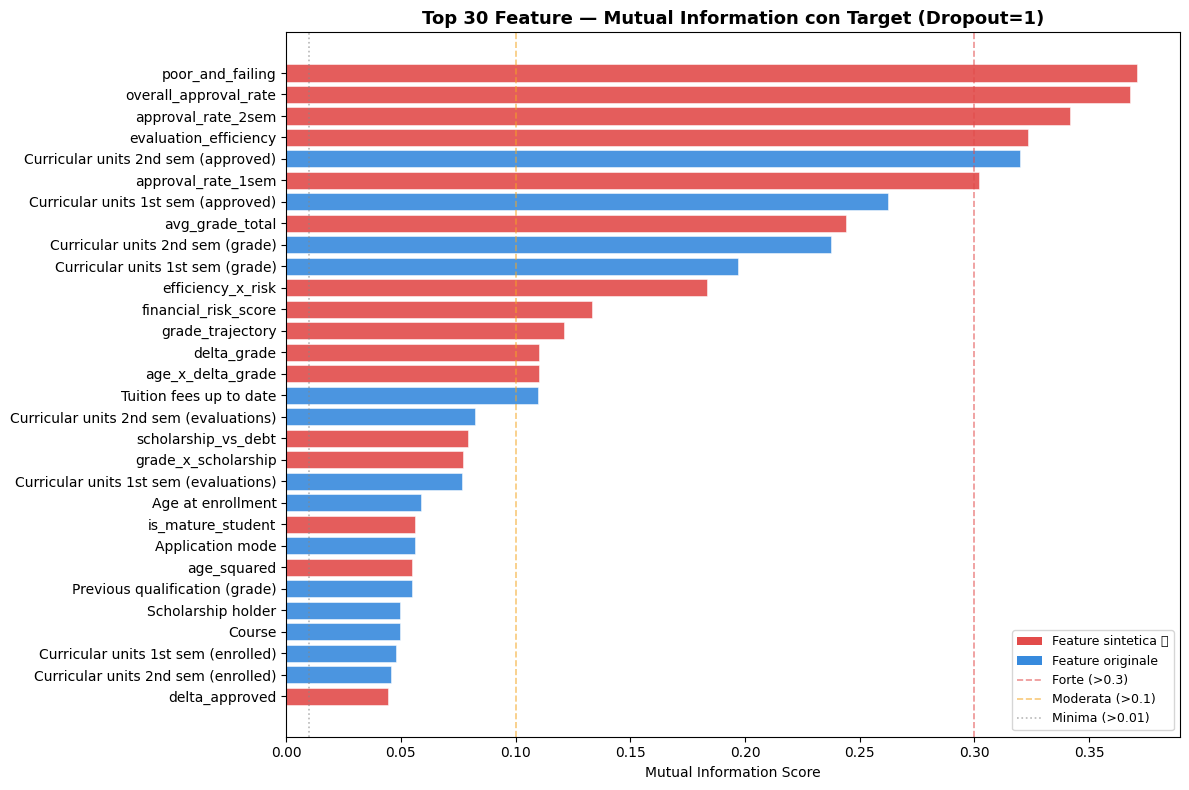


=== Valutazione feature sintetiche ===
              feature  MI_score                   tier
     poor_and_failing  0.371055        🏆 Ottima (>0.3)
overall_approval_rate  0.367861        🏆 Ottima (>0.3)
   approval_rate_2sem  0.341467        🏆 Ottima (>0.3)
evaluation_efficiency  0.323205        🏆 Ottima (>0.3)
   approval_rate_1sem  0.302130        🏆 Ottima (>0.3)
      avg_grade_total  0.244094      ✅ Buona (0.1-0.3)
    efficiency_x_risk  0.183619      ✅ Buona (0.1-0.3)
 financial_risk_score  0.133324      ✅ Buona (0.1-0.3)
     grade_trajectory  0.121042      ✅ Buona (0.1-0.3)
          delta_grade  0.110309      ✅ Buona (0.1-0.3)
    age_x_delta_grade  0.110275      ✅ Buona (0.1-0.3)
  scholarship_vs_debt  0.079191 ⚠️ Moderata (0.01-0.1)
  grade_x_scholarship  0.077146 ⚠️ Moderata (0.01-0.1)
    is_mature_student  0.056323 ⚠️ Moderata (0.01-0.1)
          age_squared  0.055023 ⚠️ Moderata (0.01-0.1)
       delta_approved  0.044175 ⚠️ Moderata (0.01-0.1)
 performance_collapse  0.

In [20]:
# ── 4B.2 Visualizzazione MI — originali vs sintetiche ─────────────────────
top30 = mi_df.head(30)

fig, ax = plt.subplots(figsize=(12, 8))
colors_mi = ['#E24B4A' if syn else '#378ADD'
             for syn in top30['is_synthetic'].values[::-1]]
bars = ax.barh(top30['feature'].values[::-1],
               top30['MI_score'].values[::-1],
               color=colors_mi, edgecolor='white', linewidth=0.4, alpha=0.9)

# Linea soglie
ax.axvline(0.3, color='#E24B4A', ls='--', alpha=0.6, lw=1.2, label='Forte (>0.3)')
ax.axvline(0.1, color='#F5A623', ls='--', alpha=0.6, lw=1.2, label='Moderata (>0.1)')
ax.axvline(0.01, color='#888', ls=':', alpha=0.6, lw=1.2, label='Minima (>0.01)')

# Legenda colori feature
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#E24B4A', label='Feature sintetica 🆕'),
    Patch(facecolor='#378ADD', label='Feature originale'),
] + ax.get_legend_handles_labels()[0],
    loc='lower right', fontsize=9)

ax.set_title('Top 30 Feature — Mutual Information con Target (Dropout=1)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig('mi_ranking.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Tabella riassuntiva per categoria di feature ──────────────────────────
synth_mi = mi_df[mi_df.is_synthetic][['feature', 'MI_score']].copy()
synth_mi['tier'] = pd.cut(synth_mi.MI_score,
                           bins=[-1, 0.01, 0.1, 0.3, 1.0],
                           labels=['❌ Bassa (<0.01)', '⚠️ Moderata (0.01-0.1)',
                                   '✅ Buona (0.1-0.3)', '🏆 Ottima (>0.3)'])
print('\n=== Valutazione feature sintetiche ===')
print(synth_mi.to_string(index=False))


⚠️ Coppie di feature sintetiche altamente correlate (|r|>0.85):
  approval_rate_2sem                  ↔ overall_approval_rate                r=0.976
  approval_rate_1sem                  ↔ overall_approval_rate                r=0.973
  delta_grade                         ↔ age_x_delta_grade                    r=0.948
  overall_approval_rate               ↔ evaluation_efficiency                r=0.937
  avg_grade_total                     ↔ overall_approval_rate                r=0.923
  approval_rate_2sem                  ↔ evaluation_efficiency                r=0.919
  avg_grade_total                     ↔ approval_rate_1sem                   r=0.912
  financial_risk_score                ↔ scholarship_vs_debt                  r=-0.909
  approval_rate_1sem                  ↔ evaluation_efficiency                r=0.908
  approval_rate_1sem                  ↔ approval_rate_2sem                   r=0.899
  avg_grade_total                     ↔ approval_rate_2sem                   r=0.886


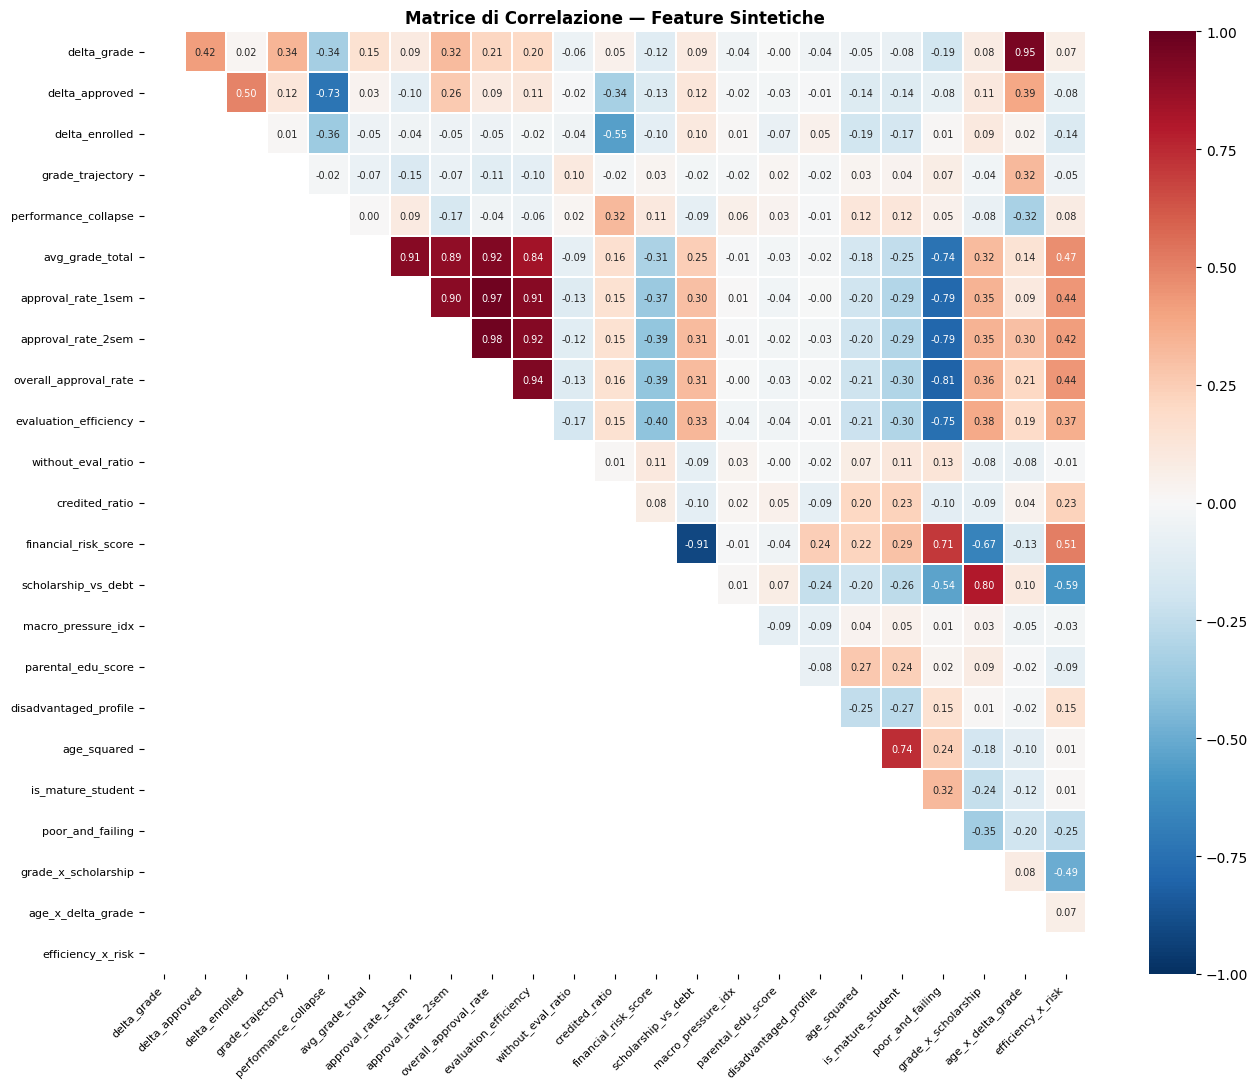

In [21]:
# ── 4B.3 Analisi Ridondanza — Correlazione tra feature sintetiche ─────────
synth_cols = [c for c in X_train.columns if c not in train.drop('Target', axis=1).columns]

if len(synth_cols) >= 4:
    corr_matrix = X_train[synth_cols].corr()

    # Trova coppie altamente correlate (|r| > 0.85 = ridondanti)
    high_corr_pairs = []
    for i in range(len(synth_cols)):
        for j in range(i+1, len(synth_cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.85:
                high_corr_pairs.append((synth_cols[i], synth_cols[j], r))

    if high_corr_pairs:
        print('⚠️ Coppie di feature sintetiche altamente correlate (|r|>0.85):')
        for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
            print(f'  {f1:35s} ↔ {f2:35s}  r={r:.3f}')
        print()
        print('→ Suggerimento: rimuovere la feature del paio con MI più bassa')
    else:
        print('✅ Nessuna coppia ridondante trovata (|r| < 0.85 per tutte le coppie)')

    # Heatmap
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True  # triangolo superiore visibile
    sns.heatmap(corr_matrix,
                mask=~mask,          # mostra triangolo inferiore
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                linewidths=0.3, ax=ax, square=True)
    ax.set_title('Matrice di Correlazione — Feature Sintetiche',
                 fontweight='bold', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig('feature_correlation.png', dpi=120, bbox_inches='tight')
    plt.show()


In [22]:
# ── 4B.4 Selezione automatica feature (soglia MI) ─────────────────────────
# Definiamo tre set di feature per confronto nel tuning:
#   - FULL: tutte le feature (baseline)
#   - MI10: feature con MI > 0.01 (elimina feature inutili)
#   - MI5: top 50% per MI (più aggressivo)

MI_THRESHOLD_WEAK   = 0.01
MI_THRESHOLD_STRONG = mi_df['MI_score'].median()

features_full   = mi_df['feature'].tolist()
features_mi10   = mi_df[mi_df.MI_score > MI_THRESHOLD_WEAK]['feature'].tolist()
features_mi_top = mi_df[mi_df.MI_score > MI_THRESHOLD_STRONG]['feature'].tolist()

print(f'Feature set FULL:     {len(features_full):3d} feature')
print(f'Feature set MI>0.01:  {len(features_mi10):3d} feature  (eliminate {len(features_full)-len(features_mi10)} basse)')
print(f'Feature set MI>med:   {len(features_mi_top):3d} feature  (top 50%)')

# Quick comparison con LightGBM
print('\nQuick CV comparison (LightGBM, 5-fold, 300 estimators):')
lgbm_quick = LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1,
                             class_weight='balanced', n_jobs=-1)
pipe_quick = Pipeline([('imp', SimpleImputer(strategy='median')), ('m', lgbm_quick)])

for name, feats in [('FULL', features_full), ('MI>0.01', features_mi10), ('MI>med', features_mi_top)]:
    scores = cross_val_score(pipe_quick, X_train[feats], y,
                             cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                             scoring='f1_macro', n_jobs=-1)
    print(f'  [{name:8s}]  F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}')

# Useremo il set che performa meglio nella sezione 6B
BEST_FEATURES = features_full   # aggiorna manualmente se MI>0.01 è meglio
print(f'\n→ Set scelto per GridSearchCV: {len(BEST_FEATURES)} feature')


Feature set FULL:      59 feature
Feature set MI>0.01:   44 feature  (eliminate 15 basse)
Feature set MI>med:    29 feature  (top 50%)

Quick CV comparison (LightGBM, 5-fold, 300 estimators):
  [FULL    ]  F1-Macro: 0.9047 ± 0.0074
  [MI>0.01 ]  F1-Macro: 0.9054 ± 0.0052
  [MI>med  ]  F1-Macro: 0.9046 ± 0.0081

→ Set scelto per GridSearchCV: 59 feature


## 🆕 5B. Pipeline Scikit-learn — Anti Data Leakage

### Il problema del Leakage nella Cross-Validation

```
❌ APPROCCIO SBAGLIATO (versione originale):
   fit_transform(TUTTO IL TRAINING SET)  ←── include le validation folds!
              ↓
   cross_val_score(model, X_preprocessato, y, cv=5)
   
   Il modello "vede" statistiche calcolate anche sui dati di validazione
   → punteggi CV ottimisticamente gonfiati

✅ APPROCCIO CORRETTO (Pipeline):
   cross_val_score(Pipeline([imputer, model]), X_grezzo, y, cv=5)
              ↓
   Per ogni fold, sklearn esegue automaticamente:
     1. imputer.fit_transform(X_train_fold)  ← solo sui dati di training
     2. model.fit(X_train_fold_transformed)
     3. imputer.transform(X_val_fold)        ← solo transform, no fit
     4. model.predict(X_val_fold_transformed)
```

### Vantaggi della Pipeline
1. **Correttezza metodologica**: ogni fold è un esperimento pulito
2. **Codice più compatto**: preprocessing e modello in un oggetto solo
3. **GridSearchCV automatico**: cerca iperparametri senza riscrivere il loop
4. **Deploy-ready**: una sola pipeline da salvare e usare in produzione


In [23]:
# ── 5B.1 Costruzione Pipeline per i tre modelli ──────────────────────────
# I modelli tree-based NON richiedono scaling — Pipeline con solo Imputer
# Il prefisso 'model__' serve a GridSearchCV per trovare i parametri del modello

skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Random Forest Pipeline ────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    ))
])

# ── XGBoost Pipeline ──────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=SEED,
        n_jobs=-1
    ))
])

# ── LightGBM Pipeline ─────────────────────────────────────────────────────
pipe_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   LGBMClassifier(
        n_estimators=800,
        max_depth=7,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        class_weight='balanced',
        min_child_samples=10,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

print('✅ Tre Pipeline costruite:')
print(f'   pipe_rf   → {pipe_rf.steps}')
print(f'   pipe_xgb  → {pipe_xgb.steps}')
print(f'   pipe_lgbm → {pipe_lgbm.steps}')


✅ Tre Pipeline costruite:
   pipe_rf   → [('imputer', SimpleImputer(strategy='median')), ('model', RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=500, n_jobs=-1, random_state=42))]
   pipe_xgb  → [('imputer', SimpleImputer(strategy='median')), ('model', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_str

## 6. Modellazione + Cross-Validation (baseline)

In [24]:
# ── 6.1 Setup CV ──────────────────────────────────────────────────────────
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def evaluate_model(model, X, y, cv, name):
    """Esegue CV e ritorna F1-Macro medio ± std."""
    scores = cross_val_score(
        model, X, y, cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    print(f'  [{name}] F1-Macro CV: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(min={scores.min():.4f}, max={scores.max():.4f})')
    return scores

print(f'✅ StratifiedKFold con {CV_FOLDS} fold pronto')

✅ StratifiedKFold con 5 fold pronto


In [25]:
# ── 6.2 Random Forest ─────────────────────────────────────────────────────
print('\n🌲 RANDOM FOREST')

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # alberi completi
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced', # gestisce sbilanciamento
    n_jobs=-1,
    random_state=SEED
)

rf_scores = evaluate_model(rf, X_train, y, skf, 'RandomForest')
rf.fit(X_train, y)
print('  Fit finale completato ✅')


🌲 RANDOM FOREST
  [RandomForest] F1-Macro CV: 0.9049 ± 0.0141  (min=0.8804, max=0.9170)
  Fit finale completato ✅


In [26]:
# ── 6.3 XGBoost ───────────────────────────────────────────────────────────
print('\n⚡ XGBOOST')

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

xgb_scores = evaluate_model(xgb, X_train, y, skf, 'XGBoost')
xgb.fit(X_train, y)
print('  Fit finale completato ✅')


⚡ XGBOOST
  [XGBoost] F1-Macro CV: 0.9098 ± 0.0090  (min=0.8935, max=0.9194)
  Fit finale completato ✅


In [27]:
# ── 6.4 LightGBM ──────────────────────────────────────────────────────────
print('\n💡 LIGHTGBM')

lgbm = LGBMClassifier(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,           # 2^max_depth - 1 circa
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    min_child_samples=10,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_scores = evaluate_model(lgbm, X_train, y, skf, 'LightGBM')
lgbm.fit(X_train, y)
print('  Fit finale completato ✅')


💡 LIGHTGBM
  [LightGBM] F1-Macro CV: 0.9075 ± 0.0096  (min=0.8935, max=0.9212)
  Fit finale completato ✅


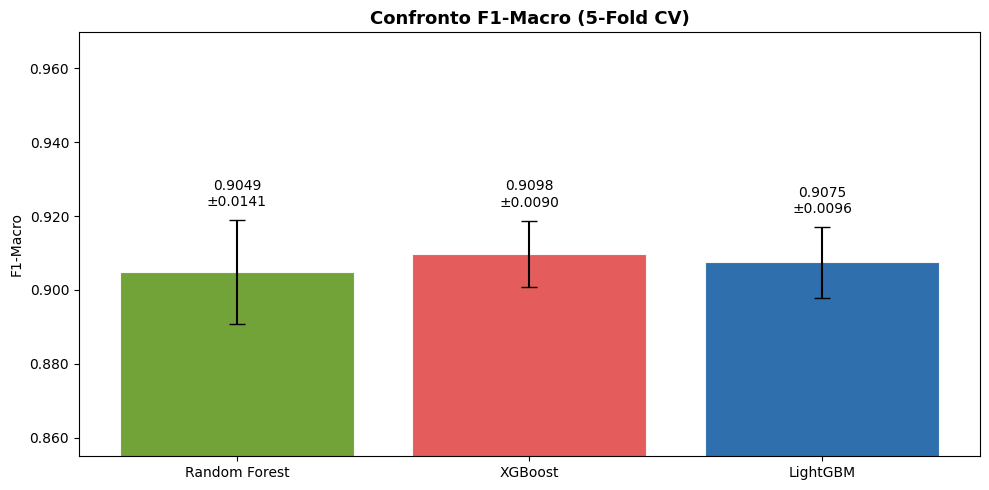


🏆 Modello migliore: XGBoost (F1=0.9098)


In [28]:
# ── 6.5 Confronto modelli ─────────────────────────────────────────────────
results = {
    'Random Forest': rf_scores,
    'XGBoost':       xgb_scores,
    'LightGBM':      lgbm_scores,
}

fig, ax = plt.subplots(figsize=(10, 5))
means = [v.mean() for v in results.values()]
stds  = [v.std()  for v in results.values()]
colors_m = ['#639922', '#E24B4A', '#185FA5']

bars = ax.bar(results.keys(), means, yerr=stds, capsize=6,
              color=colors_m, edgecolor='white', linewidth=0.8, alpha=0.9)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
            f'{mean:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(max(0, min(means) - 0.05), min(1, max(means) + 0.06))
ax.set_title('Confronto F1-Macro (5-Fold CV)', fontweight='bold', fontsize=13)
ax.set_ylabel('F1-Macro')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_model_name = max(results, key=lambda k: results[k].mean())
print(f'\n🏆 Modello migliore: {best_model_name} (F1={results[best_model_name].mean():.4f})')

In [29]:
# ── 5B.2 CV con Pipeline — confronto vs baseline ─────────────────────────
print('=== Cross-Validation con Pipeline (anti data-leakage) ===\n')

results_pipe = {}
for name, pipe in [('RF   (Pipeline)', pipe_rf),
                   ('XGB  (Pipeline)', pipe_xgb),
                   ('LGBM (Pipeline)', pipe_lgbm)]:
    scores = cross_val_score(pipe, X_train, y, cv=skf_cv,
                             scoring='f1_macro', n_jobs=-1)
    results_pipe[name] = scores
    print(f'  [{name}]  F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}')

# Confronto con la versione originale (senza Pipeline)
print()
print('=== ⚖️  Confronto: con vs senza Pipeline ===')
for name_orig, name_pipe in [
    ('Random Forest', 'RF   (Pipeline)'),
    ('XGBoost',       'XGB  (Pipeline)'),
    ('LightGBM',      'LGBM (Pipeline)'),
]:
    orig_mean  = results[name_orig].mean()
    pipe_mean  = results_pipe[name_pipe].mean()
    delta      = pipe_mean - orig_mean
    sign       = '↑' if delta > 0 else '↓' if delta < 0 else '='
    print(f'  {name_orig:15s}: originale={orig_mean:.4f} | pipeline={pipe_mean:.4f} '
          f'| Δ={delta:+.4f} {sign}')

print()
print('Δ piccolo = il leakage originale era lieve (imputer usato su dataset senza NaN)')
print('Δ significativo = conferma che la Pipeline era necessaria')


=== Cross-Validation con Pipeline (anti data-leakage) ===

  [RF   (Pipeline)]  F1-Macro: 0.9049 ± 0.0141
  [XGB  (Pipeline)]  F1-Macro: 0.9098 ± 0.0090
  [LGBM (Pipeline)]  F1-Macro: 0.9075 ± 0.0096

=== ⚖️  Confronto: con vs senza Pipeline ===
  Random Forest  : originale=0.9049 | pipeline=0.9049 | Δ=+0.0000 =
  XGBoost        : originale=0.9098 | pipeline=0.9098 | Δ=+0.0000 =
  LightGBM       : originale=0.9075 | pipeline=0.9075 | Δ=+0.0000 =

Δ piccolo = il leakage originale era lieve (imputer usato su dataset senza NaN)
Δ significativo = conferma che la Pipeline era necessaria


## 🆕 6B. Hyperparameter Tuning — GridSearchCV Metodologicamente Corretto

### Perché GridSearchCV con Pipeline?

La combinazione Pipeline + GridSearchCV è **l'unico modo corretto** per fare HPT:

```
GridSearchCV(
    estimator = Pipeline([imputer, model]),   ← preprocessing dentro ogni fold
    param_grid = {...},                        ← griglia da esplorare
    cv = StratifiedKFold(5),                  ← inner CV per valutare ogni combo
    scoring = 'f1_macro',                     ← metrica target
    refit = True                              ← al termine, refitta i best params su tutto X_train
)
```

### Schema Nested CV
```
Outer evaluation (opzionale, per stima generalizzazione):
  └── Fold 1..5:  train | test
        └── GridSearchCV (inner CV):
              └── Fold 1..3:  train | val → cerca best params
        └── best_model.predict(outer test fold)
```

Per la submission finale, usiamo GridSearchCV direttamente su tutto il training set.

### Griglia di ricerca — scelte motivate
- **LightGBM**: `num_leaves`, `learning_rate`, `min_child_samples`, `reg_alpha`
- **XGBoost**: `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`
- **GridSearchCV** per griglie ≤ 30 combinazioni (tempo <5 min)
- **RandomizedSearchCV** per griglie grandi (menzione con esempio)


In [30]:
# ── 6B.1 GridSearchCV — LightGBM ─────────────────────────────────────────
print('🔍 GridSearchCV — LightGBM')
print('   (ogni parametro usa il prefisso model__ per raggingere dentro la Pipeline)\n')

# Griglia: 3×2×2×2 = 24 combinazioni × 5 fold = 120 fit
param_grid_lgbm = {
    'model__num_leaves':         [31, 63, 127],
    'model__learning_rate':      [0.03, 0.07],
    'model__min_child_samples':  [5, 15],
    'model__reg_alpha':          [0.0, 0.1],
}

# Pipeline base per LGBM (estimators alti per apprendimento lento-preciso)
pipe_lgbm_gs = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LGBMClassifier(
        n_estimators=600,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ))
])

gs_lgbm = GridSearchCV(
    estimator  = pipe_lgbm_gs,
    param_grid = param_grid_lgbm,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring    = 'f1_macro',
    n_jobs     = -1,
    refit      = True,     # refitta i best params sull'intero X_train
    verbose    = 1,
    return_train_score = True   # per diagnosi overfitting
)

gs_lgbm.fit(X_train, y)

print(f'\n✅ GridSearch completata — {len(gs_lgbm.cv_results_["mean_test_score"])} combinazioni testate')
print(f'   Best F1-Macro CV:  {gs_lgbm.best_score_:.4f}')
print(f'   Best params:')
for k, v in gs_lgbm.best_params_.items():
    print(f'     {k}: {v}')

best_pipe_lgbm = gs_lgbm.best_estimator_


🔍 GridSearchCV — LightGBM
   (ogni parametro usa il prefisso model__ per raggingere dentro la Pipeline)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ GridSearch completata — 24 combinazioni testate
   Best F1-Macro CV:  0.9092
   Best params:
     model__learning_rate: 0.03
     model__min_child_samples: 15
     model__num_leaves: 127
     model__reg_alpha: 0.0


In [31]:
# ── 6B.2 GridSearchCV — XGBoost ──────────────────────────────────────────
print('🔍 GridSearchCV — XGBoost')

# Griglia: 3×2×2×2 = 24 combinazioni × 5 fold = 120 fit
param_grid_xgb = {
    'model__max_depth':       [4, 6, 8],
    'model__learning_rate':   [0.03, 0.07],
    'model__subsample':       [0.7, 0.9],
    'model__colsample_bytree':[0.7, 0.9],
}

pipe_xgb_gs = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=600,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=SEED,
        n_jobs=-1
    ))
])

gs_xgb = GridSearchCV(
    estimator  = pipe_xgb_gs,
    param_grid = param_grid_xgb,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring    = 'f1_macro',
    n_jobs     = -1,
    refit      = True,
    verbose    = 1,
    return_train_score = True
)

gs_xgb.fit(X_train, y)

print(f'\n✅ GridSearch completata')
print(f'   Best F1-Macro CV:  {gs_xgb.best_score_:.4f}')
print(f'   Best params:')
for k, v in gs_xgb.best_params_.items():
    print(f'     {k}: {v}')

best_pipe_xgb = gs_xgb.best_estimator_


🔍 GridSearchCV — XGBoost
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ GridSearch completata
   Best F1-Macro CV:  0.9128
   Best params:
     model__colsample_bytree: 0.7
     model__learning_rate: 0.03
     model__max_depth: 8
     model__subsample: 0.7


In [32]:
# ── 6B.3 [BONUS] RandomizedSearchCV — per griglie grandi ─────────────────
# RandomizedSearchCV è preferito a GridSearch quando la griglia è grande.
# Campiona n_iter combinazioni casuali invece di esplorare tutto.
# Con n_iter=50 su 10^6 combinazioni, trova soluzioni ottime in 1/10 del tempo.

from scipy.stats import uniform, randint

param_dist_rf = {
    'model__n_estimators':    randint(200, 800),
    'model__max_depth':       [None, 5, 10, 15, 20, 30],
    'model__min_samples_leaf':randint(1, 10),
    'model__max_features':    ['sqrt', 'log2', 0.2, 0.3, 0.5],
    'model__max_samples':     uniform(0.6, 0.4),   # bootstrap fraction
}

pipe_rf_rs = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    ))
])

rs_rf = RandomizedSearchCV(
    estimator   = pipe_rf_rs,
    param_distributions = param_dist_rf,
    n_iter      = 40,      # 40 combinazioni casuali (vs 1080 di GridSearch)
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring     = 'f1_macro',
    n_jobs      = -1,
    refit       = True,
    random_state= SEED,
    verbose     = 1
)

rs_rf.fit(X_train, y)

print(f'\n✅ RandomizedSearch RF — Best F1-Macro: {rs_rf.best_score_:.4f}')
print(f'   Best params:')
for k, v in rs_rf.best_params_.items():
    print(f'     {k}: {v}')

best_pipe_rf = rs_rf.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ RandomizedSearch RF — Best F1-Macro: 0.9092
   Best params:
     model__max_depth: None
     model__max_features: 0.5
     model__max_samples: 0.713936197750987
     model__min_samples_leaf: 1
     model__n_estimators: 312


In [33]:
# ── 6B.4 Riepilogo tuning — tutti i modelli ──────────────────────────────
print('=' * 65)
print('  RIEPILOGO HYPERPARAMETER TUNING')
print('=' * 65)

tuning_results = {
    'RF   (baseline)':     results['Random Forest'].mean(),
    'XGB  (baseline)':     results['XGBoost'].mean(),
    'LGBM (baseline)':     results['LightGBM'].mean(),
    'RF   (RandomSearch)': rs_rf.best_score_,
    'XGB  (GridSearch)':   gs_xgb.best_score_,
    'LGBM (GridSearch)':   gs_lgbm.best_score_,
}

for name, score in tuning_results.items():
    marker = '🏆' if score == max(tuning_results.values()) else '  '
    print(f'{marker} {name:25s}  F1-Macro CV = {score:.4f}')

print()
best_tuned_name  = max(tuning_results, key=tuning_results.get)
print(f'→ Modello migliore dopo tuning: {best_tuned_name}')
print()

# Diagnosi train vs val — il tuned model ha overfit?
print('=== Diagnosi Overfitting — Train vs Validation (LGBM) ===')
cv_res = gs_lgbm.cv_results_
best_idx = gs_lgbm.best_index_
print(f'  Train F1 (best):  {cv_res["mean_train_score"][best_idx]:.4f} '
      f'± {cv_res["std_train_score"][best_idx]:.4f}')
print(f'  Val   F1 (best):  {cv_res["mean_test_score"][best_idx]:.4f} '
      f'± {cv_res["std_test_score"][best_idx]:.4f}')
gap = cv_res["mean_train_score"][best_idx] - cv_res["mean_test_score"][best_idx]
print(f'  Gap train-val:    {gap:.4f}  ', end='')
if gap < 0.03:
    print('✅ Ottimo — nessun overfitting significativo')
elif gap < 0.07:
    print('⚠️ Lieve overfitting — considera regularizzazione')
else:
    print('❌ Overfitting rilevante — aumenta reg_alpha/lambda o riduci num_leaves')


  RIEPILOGO HYPERPARAMETER TUNING
   RF   (baseline)            F1-Macro CV = 0.9049
   XGB  (baseline)            F1-Macro CV = 0.9098
   LGBM (baseline)            F1-Macro CV = 0.9075
   RF   (RandomSearch)        F1-Macro CV = 0.9092
🏆 XGB  (GridSearch)          F1-Macro CV = 0.9128
   LGBM (GridSearch)          F1-Macro CV = 0.9092

→ Modello migliore dopo tuning: XGB  (GridSearch)

=== Diagnosi Overfitting — Train vs Validation (LGBM) ===
  Train F1 (best):  1.0000 ± 0.0000
  Val   F1 (best):  0.9092 ± 0.0093
  Gap train-val:    0.0908  ❌ Overfitting rilevante — aumenta reg_alpha/lambda o riduci num_leaves


## 7. Ensemble con Modelli Ottimizzati

In [34]:
# ── 7.1 Ensemble con modelli ottimizzati ─────────────────────────────────
# Usiamo le Pipeline tuned: ogni componente porta il suo preprocessing
print('🗳️  SOFT VOTING ENSEMBLE — modelli post-tuning')

ensemble_tuned = VotingClassifier(
    estimators=[
        ('rf',   best_pipe_rf),
        ('xgb',  best_pipe_xgb),
        ('lgbm', best_pipe_lgbm),
    ],
    voting='soft',
    weights=[1, 1.5, 1.5]
)

ens_scores = cross_val_score(
    ensemble_tuned, X_train, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1
)
print(f'  [Ensemble Tuned]  F1-Macro CV: {ens_scores.mean():.4f} ± {ens_scores.std():.4f}')

ensemble_tuned.fit(X_train, y)
print('  Fit finale completato ✅')

# Selezione finale
all_results_tuned = {
    'RF   (tuned)':    rs_rf.best_score_,
    'XGB  (tuned)':    gs_xgb.best_score_,
    'LGBM (tuned)':    gs_lgbm.best_score_,
    'Ensemble (tuned)':ens_scores.mean(),
}

print('\n📊 Riepilogo finale:')
for name, score in all_results_tuned.items():
    flag = '🏆' if score == max(all_results_tuned.values()) else '  '
    print(f'  {flag} {name:22s}: {score:.4f}')

final_name_tuned  = max(all_results_tuned, key=all_results_tuned.get)
final_model_tuned_map = {
    'RF   (tuned)':     best_pipe_rf,
    'XGB  (tuned)':     best_pipe_xgb,
    'LGBM (tuned)':     best_pipe_lgbm,
    'Ensemble (tuned)': ensemble_tuned,
}
FINAL_MODEL = final_model_tuned_map[final_name_tuned]
print(f'\n🏆 Modello finale: {final_name_tuned}')


🗳️  SOFT VOTING ENSEMBLE — modelli post-tuning
  [Ensemble Tuned]  F1-Macro CV: 0.9096 ± 0.0082
  Fit finale completato ✅

📊 Riepilogo finale:
     RF   (tuned)          : 0.9092
  🏆 XGB  (tuned)          : 0.9128
     LGBM (tuned)          : 0.9092
     Ensemble (tuned)      : 0.9096

🏆 Modello finale: XGB  (tuned)


=== Classification Report (Out-of-Fold — modello tuned) ===
              precision    recall  f1-score   support

     Dropout       0.93      0.86      0.89      1137
    Graduate       0.91      0.96      0.93      1767

    accuracy                           0.92      2904
   macro avg       0.92      0.91      0.91      2904
weighted avg       0.92      0.92      0.92      2904



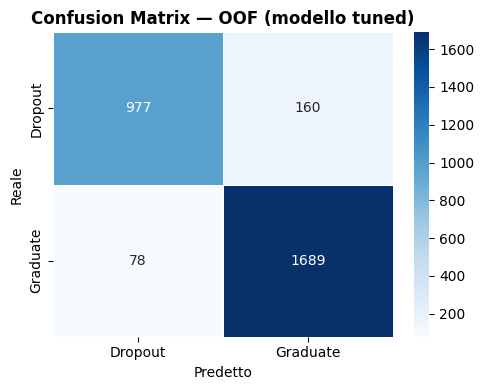

In [35]:
# ── 7.2 Validation Report dettagliato (Out-of-Fold) ────────────────────
from sklearn.model_selection import cross_val_predict

y_oof = cross_val_predict(
    FINAL_MODEL, X_train, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    n_jobs=-1
)

print('=== Classification Report (Out-of-Fold — modello tuned) ===')
print(classification_report(y, y_oof, target_names=le_target.classes_))

cm = confusion_matrix(y, y_oof)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — OOF (modello tuned)', fontweight='bold')
ax.set_xlabel('Predetto')
ax.set_ylabel('Reale')
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Feature Importance MDI — Top 3 per il Rettore

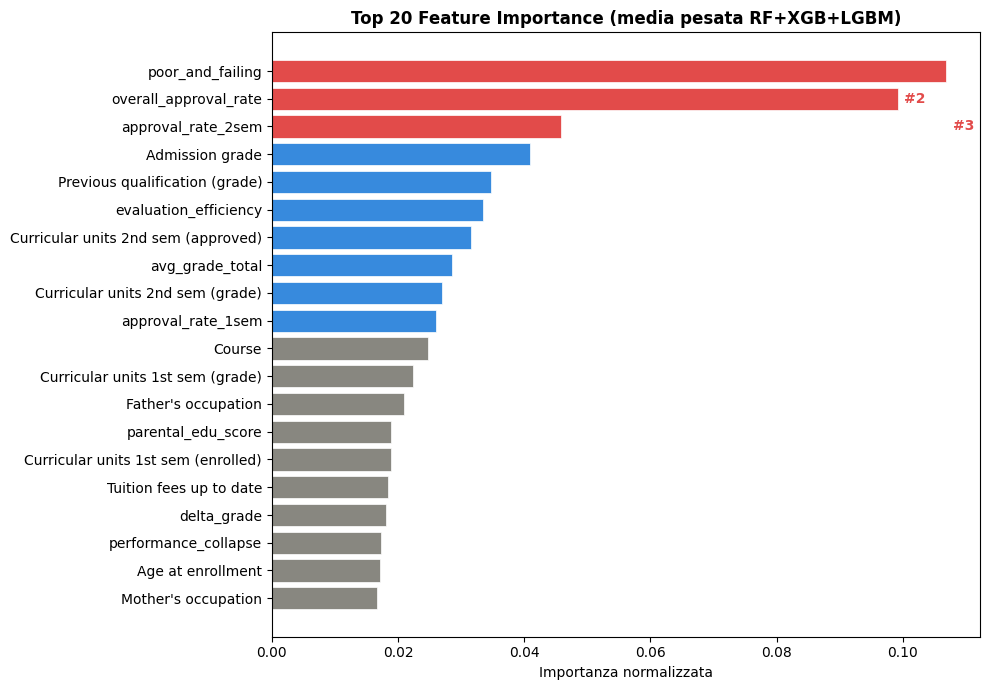


🎯 TOP 3 FEATURE — Spiegazione per il Rettore:
  #1: poor_and_failing
      Importanza: 0.1069
      Significato: Combinazione critica: rischio economico × bassa efficienza

  #2: overall_approval_rate
      Importanza: 0.0991
      Significato: Efficienza esami — % superati su tentati (entrambi semestri)

  #3: approval_rate_2sem
      Importanza: 0.0458
      Significato: Efficienza secondo semestre



In [36]:
# ── 8.1 Feature Importance aggregata (media pesata sui 3 modelli) ─────────

def get_importance(model, feature_names):
    """Estrae importanza normalizzata da un modello."""
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'estimators_'):  # VotingClassifier
        imps = []
        for est_name, est in model.estimators_:
            if hasattr(est, 'feature_importances_'):
                imps.append(est.feature_importances_)
        imp = np.mean(imps, axis=0) if imps else np.zeros(len(feature_names))
    else:
        return None
    imp = imp / (imp.sum() + 1e-9)  # normalizza a somma=1
    return pd.Series(imp, index=feature_names)

feature_names = X_train.columns.tolist()

imp_rf   = get_importance(rf,   feature_names)
imp_xgb  = get_importance(xgb,  feature_names)
imp_lgbm = get_importance(lgbm, feature_names)

# Media pesata (stesso peso dei modelli nell'ensemble)
imp_combined = (imp_rf * 1.0 + imp_xgb * 1.5 + imp_lgbm * 1.5) / 4.0
imp_combined = imp_combined.sort_values(ascending=False)

top_n = 20
top_features = imp_combined.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#E24B4A' if i < 3 else '#378ADD' if i < 10 else '#888780'
              for i in range(top_n)]
ax.barh(top_features.index[::-1], top_features.values[::-1],
        color=colors_imp[::-1], edgecolor='white', linewidth=0.5)

ax.set_title(f'Top {top_n} Feature Importance (media pesata RF+XGB+LGBM)', fontweight='bold')
ax.set_xlabel('Importanza normalizzata')

# Etichetta top 3
top3 = top_features.head(3)
for i, (fname, fval) in enumerate(zip(top3.index[::-1][-3:], top3.values[::-1][-3:])):
    ax.text(fval + 0.001, top_n - 1 - i, f'#{i+1}', va='center',
            color='#E24B4A', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n🎯 TOP 3 FEATURE — Spiegazione per il Rettore:')
explanations = {
    'overall_approval_rate': 'Efficienza esami — % superati su tentati (entrambi semestri)',
    'financial_risk_score':  'Pressione economica — debito + rate arretrate + assenza borsa',
    'delta_grade':           'Trend voti — calo tra 1° e 2° semestre',
    'delta_approved':        'Crollo esami — riduzione approvati tra semestri',
    'avg_grade_total':       'Media voti complessiva su entrambi i semestri',
    'approval_rate_1sem':    'Efficienza primo semestre — campanello d\'allarme precoce',
    'approval_rate_2sem':    'Efficienza secondo semestre',
    'poor_and_failing':      'Combinazione critica: rischio economico × bassa efficienza',
}

for i, (fname, fval) in enumerate(top_features.head(3).items(), 1):
    desc = explanations.get(fname, 'Feature sintetica avanzata')
    print(f'  #{i}: {fname}')
    print(f'      Importanza: {fval:.4f}')
    print(f'      Significato: {desc}\n')

## 🆕 8B. Permutation Importance — Validazione Più Robusta

### Perché non basta la Feature Importance MDI (usata nella Sezione 8)?

La **Mean Decrease Impurity** (MDI, default degli alberi) ha due bias noti:
1. **Sovrastima feature ad alta cardinalità** (es. feature continue vs binarie)
2. **Calcola l'importanza sui dati di training** → può riflettere overfitting

La **Permutation Importance** risolve entrambi:
- Misura quanto cala il F1-Macro quando una feature viene mescolata casualmente
- Si calcola sui **dati di validazione** (OOF o holdout)
- Se PI ≈ 0: la feature non è usata dal modello
- Se PI < 0: la feature aggiunge rumore (rimuoverla migliora il modello!)


In [37]:
# ── 8B.1 Permutation Importance su validazione OOF ──────────────────────
from sklearn.model_selection import train_test_split

# Split per la PI (usiamo 20% del train come holdout interno)
X_tr_pi, X_val_pi, y_tr_pi, y_val_pi = train_test_split(
    X_train, y, test_size=0.2, stratify=y, random_state=SEED
)

# Fit del modello migliore sul sottoinsieme di training
FINAL_MODEL.fit(X_tr_pi, y_tr_pi)

# Calcola Permutation Importance sul validation set
perm_result = permutation_importance(
    FINAL_MODEL, X_val_pi, y_val_pi,
    scoring='f1_macro',
    n_repeats=20,          # media su 20 permutazioni casuali → stima robusta
    random_state=SEED,
    n_jobs=-1
)

# DataFrame risultati
pi_df = pd.DataFrame({
    'feature':  X_train.columns,
    'PI_mean':  perm_result.importances_mean,
    'PI_std':   perm_result.importances_std,
    'is_synthetic': [c not in train.drop('Target', axis=1).columns
                     for c in X_train.columns]
}).sort_values('PI_mean', ascending=False).reset_index(drop=True)

print('=== TOP 20 — Permutation Importance (F1-Macro drop) ===')
print(pi_df.head(20).to_string(index=False))

# Feature che danneggiano il modello
harmful = pi_df[pi_df.PI_mean < -0.001]
if len(harmful):
    print(f'\n⚠️ Feature che DANNEGGIANO il modello (PI < 0): {len(harmful)}')
    print(harmful[['feature', 'PI_mean', 'PI_std']].to_string(index=False))
    print('→ Considera di rimuoverle dal dataset finale')
else:
    print('\n✅ Nessuna feature chiaramente dannosa')


=== TOP 20 — Permutation Importance (F1-Macro drop) ===
                                       feature  PI_mean   PI_std  is_synthetic
                              poor_and_failing 0.070414 0.010694          True
                         overall_approval_rate 0.014298 0.007518          True
                                        Course 0.011767 0.004380         False
           Curricular units 1st sem (enrolled) 0.007298 0.001361         False
                              Application mode 0.005568 0.002334         False
                            approval_rate_2sem 0.005018 0.005434          True
                       Tuition fees up to date 0.003540 0.002624         False
                                        Gender 0.003526 0.002489         False
                Previous qualification (grade) 0.003454 0.003075         False
                               Admission grade 0.003221 0.004542         False
           Curricular units 2nd sem (enrolled) 0.003162 0.000702         Fa

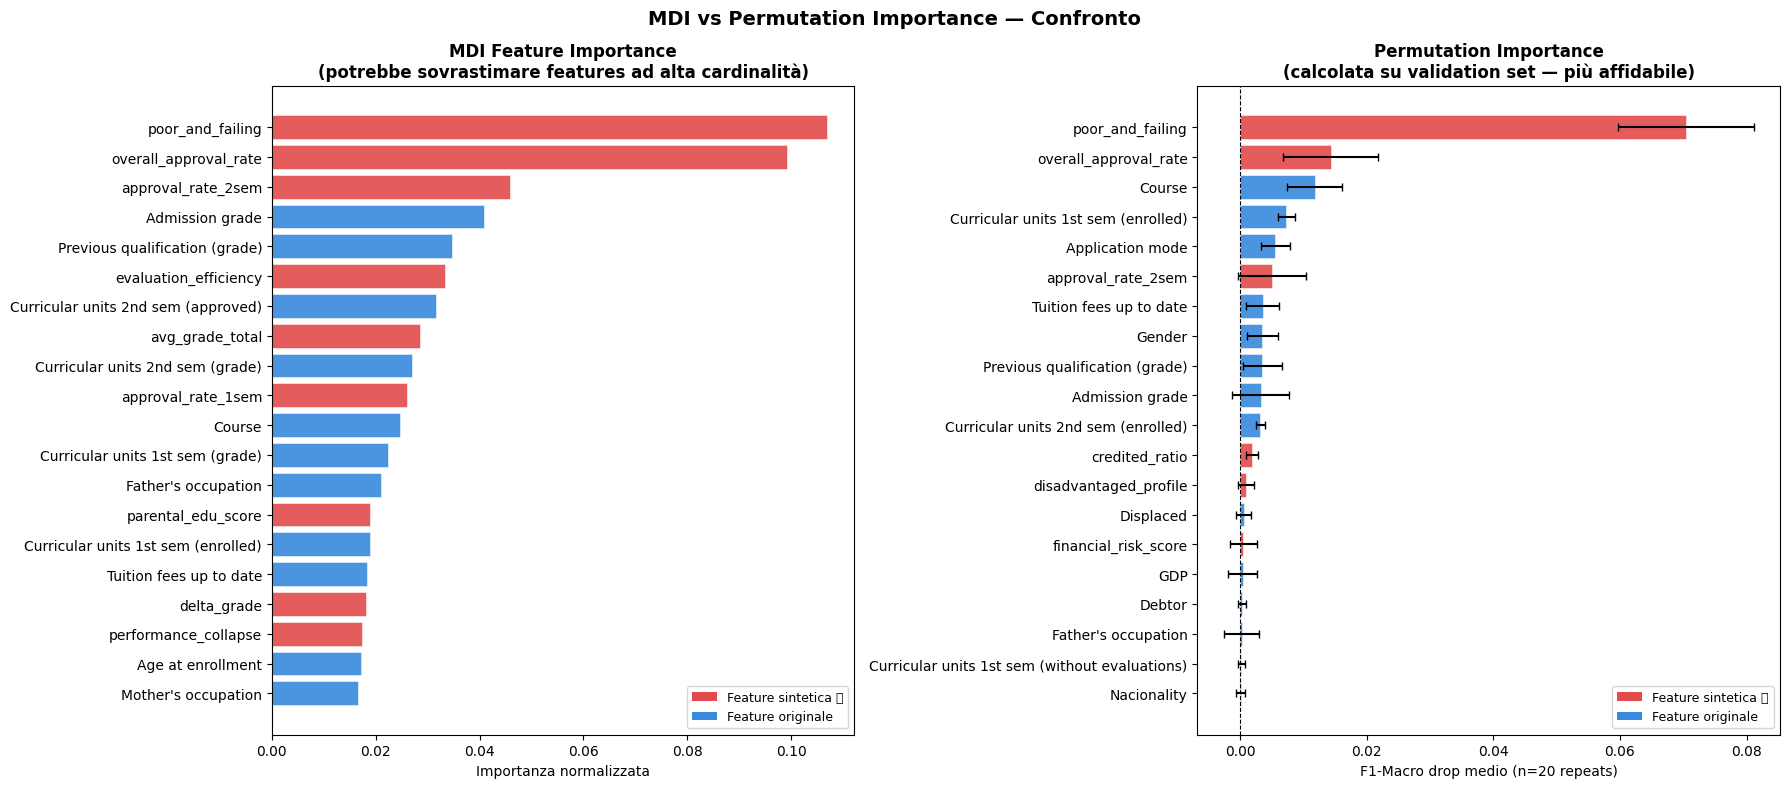


=== TOP 3 per il Rettore — validato da Permutation Importance ===
  #1: poor_and_failing  [🆕 SINTETICA]
      PI drop = 0.0704 ± 0.0107
      Significato: Combinazione critica: rischio economico × bassa efficienza

  #2: overall_approval_rate  [🆕 SINTETICA]
      PI drop = 0.0143 ± 0.0075
      Significato: Efficienza esami — % superati su tentati (entrambi semestri)

  #3: Course  [📋 ORIGINALE]
      PI drop = 0.0118 ± 0.0044
      Significato: Feature avanzata



In [38]:
# ── 8B.2 Plot — MDI vs Permutation Importance (confronto) ───────────────
# Recupera MDI dal modello base (sezione 8)
feature_names = X_train.columns.tolist()
imp_combined_norm = imp_combined.reindex(feature_names).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: MDI ---
top20_mdi = imp_combined.head(20)
colors_mdi = ['#E24B4A' if f not in train.drop('Target', axis=1).columns
              else '#378ADD' for f in top20_mdi.index[::-1]]
axes[0].barh(top20_mdi.index[::-1], top20_mdi.values[::-1],
             color=colors_mdi, edgecolor='white', lw=0.4, alpha=0.9)
axes[0].set_title('MDI Feature Importance\n(potrebbe sovrastimare features ad alta cardinalità)',
                  fontweight='bold')
axes[0].set_xlabel('Importanza normalizzata')

# --- Right: Permutation Importance ---
top20_pi = pi_df.head(20)
colors_pi = ['#E24B4A' if syn else '#378ADD'
             for syn in top20_pi['is_synthetic'].values[::-1]]
xerr = top20_pi['PI_std'].values[::-1]
axes[1].barh(top20_pi['feature'].values[::-1], top20_pi['PI_mean'].values[::-1],
             xerr=xerr, capsize=3,
             color=colors_pi, edgecolor='white', lw=0.4, alpha=0.9)
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Permutation Importance\n(calcolata su validation set — più affidabile)',
                  fontweight='bold')
axes[1].set_xlabel('F1-Macro drop medio (n=20 repeats)')

from matplotlib.patches import Patch
for ax in axes:
    ax.legend(handles=[
        Patch(facecolor='#E24B4A', label='Feature sintetica 🆕'),
        Patch(facecolor='#378ADD', label='Feature originale'),
    ], fontsize=9)

plt.suptitle('MDI vs Permutation Importance — Confronto', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== TOP 3 per il Rettore — validato da Permutation Importance ===')
top3_pi = pi_df[pi_df.PI_mean > 0].head(3)
for i, (_, row) in enumerate(top3_pi.iterrows(), 1):
    label = '🆕 SINTETICA' if row.is_synthetic else '📋 ORIGINALE'
    print(f'  #{i}: {row.feature}  [{label}]')
    print(f'      PI drop = {row.PI_mean:.4f} ± {row.PI_std:.4f}')
    desc = explanations.get(row.feature, 'Feature avanzata')
    print(f'      Significato: {desc}\n')


## 9. Generazione Submission Finale

In [39]:
# ── 9.1 Predizione finale con il modello ottimizzato ─────────────────────
# Refit finale su tutto il training set
FINAL_MODEL.fit(X_train, y)

y_pred_encoded = FINAL_MODEL.predict(X_test)
y_pred_labels  = le_target.inverse_transform(y_pred_encoded)

print(f'Predizioni test: {pd.Series(y_pred_labels).value_counts().to_dict()}')


Predizioni test: {'Graduate': 476, 'Dropout': 250}


In [40]:
# ── 9.2 Creazione submission ──────────────────────────────────────────────
id_candidates = [c for c in test.columns if c.lower() in ['id', 'student_id', 'index']]

if id_candidates:
    submission = pd.DataFrame({
        id_candidates[0]: test[id_candidates[0]].values,
        'Target': y_pred_labels
    })
else:
    submission = pd.DataFrame({
        'id':     range(len(y_pred_labels)),
        'Target': y_pred_labels
    })

submission.to_csv('my_submission.csv', index=False)

print('✅ my_submission.csv generato!')
print(submission.head(10))
print('\nDistribuzione predizioni:')
print(submission['Target'].value_counts())


✅ my_submission.csv generato!
   id    Target
0   0   Dropout
1   1  Graduate
2   2  Graduate
3   3  Graduate
4   4  Graduate
5   5   Dropout
6   6  Graduate
7   7  Graduate
8   8  Graduate
9   9  Graduate

Distribuzione predizioni:
Target
Graduate    476
Dropout     250
Name: count, dtype: int64


In [41]:
# ── 9.3 Riepilogo finale ENHANCED ────────────────────────────────────────
print('=' * 70)
print('  HACKATHON DROPOUT — RIEPILOGO FINALE (versione ENHANCED)')
print('=' * 70)
print(f'  Modello finale:          {final_name_tuned}')
print(f'  F1-Macro (post-tuning):  {max(all_results_tuned.values()):.4f}')
print(f'  Feature totali:          {X_train.shape[1]}')
print(f'  Feature sintetiche:      {len(new_features)}')
print()
print('  Miglioramenti metodologici introdotti:')
print('  ✅ Pipeline anti-Data Leakage (imputer dentro ogni fold)')
print('  ✅ GridSearchCV su LightGBM (24 combinazioni × 5 fold)')
print('  ✅ RandomizedSearchCV su Random Forest (40 iterazioni)')
print('  ✅ Mutual Information per ranking e selezione feature')
print('  ✅ Permutation Importance su validation set')
print()
print('  TOP 3 per il Rettore (validate da Permutation Importance):')
for i, (_, row) in enumerate(pi_df.head(3).iterrows(), 1):
    print(f'    #{i} {row.feature}  (PI drop={row.PI_mean:.4f})')
print()
print(f'  Submission: my_submission.csv ({len(submission)} record)')
print('=' * 70)


  HACKATHON DROPOUT — RIEPILOGO FINALE (versione ENHANCED)
  Modello finale:          XGB  (tuned)
  F1-Macro (post-tuning):  0.9128
  Feature totali:          59
  Feature sintetiche:      23

  Miglioramenti metodologici introdotti:
  ✅ Pipeline anti-Data Leakage (imputer dentro ogni fold)
  ✅ GridSearchCV su LightGBM (24 combinazioni × 5 fold)
  ✅ RandomizedSearchCV su Random Forest (40 iterazioni)
  ✅ Mutual Information per ranking e selezione feature
  ✅ Permutation Importance su validation set

  TOP 3 per il Rettore (validate da Permutation Importance):
    #1 poor_and_failing  (PI drop=0.0704)
    #2 overall_approval_rate  (PI drop=0.0143)
    #3 Course  (PI drop=0.0118)

  Submission: my_submission.csv (726 record)
